# Titanic Survival Prediction with Logistic Regression
Simple and clear workflow using the original Titanic dataset.

In [4]:
#pip install sklearn

In [5]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay


In [6]:
#loading data
df = pd.read_csv('titanic_train.csv')
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [7]:
df['Sex'].value_counts(dropna=False)

Sex
male      577
female    314
Name: count, dtype: int64

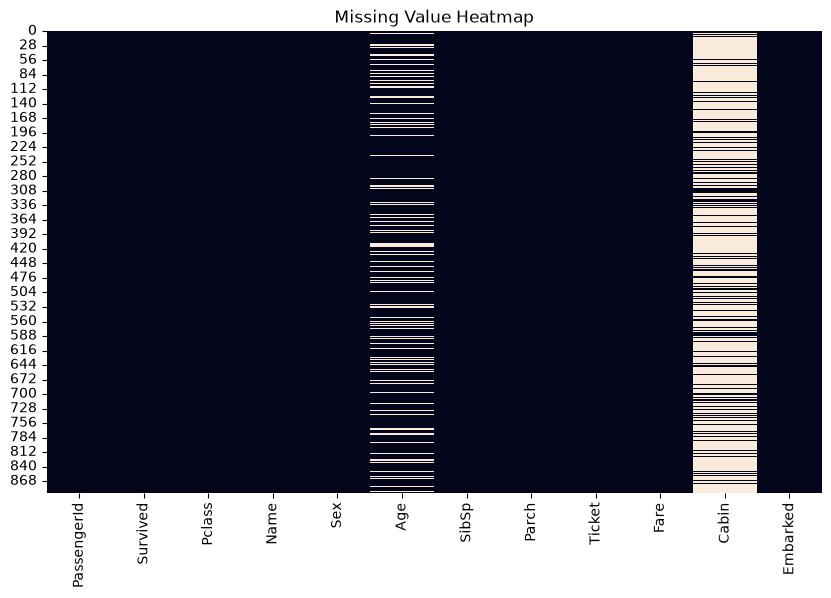

In [8]:
#heatmap of data
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(),cbar=False)



plt.title('Missing Value Heatmap')

plt.show()

In [9]:
# fixing data
df['Age']=df['Age'].fillna(df['Age'].median())


df['Fare']=df['Fare'].fillna(df['Fare'].median())

df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])

features=['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']


X=df[features]
y=df['Survived']


X=pd.get_dummies(X,columns=['Sex','Embarked'],drop_first=True)
X.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


In [10]:
X['Sex_male'].dtype

dtype('bool')

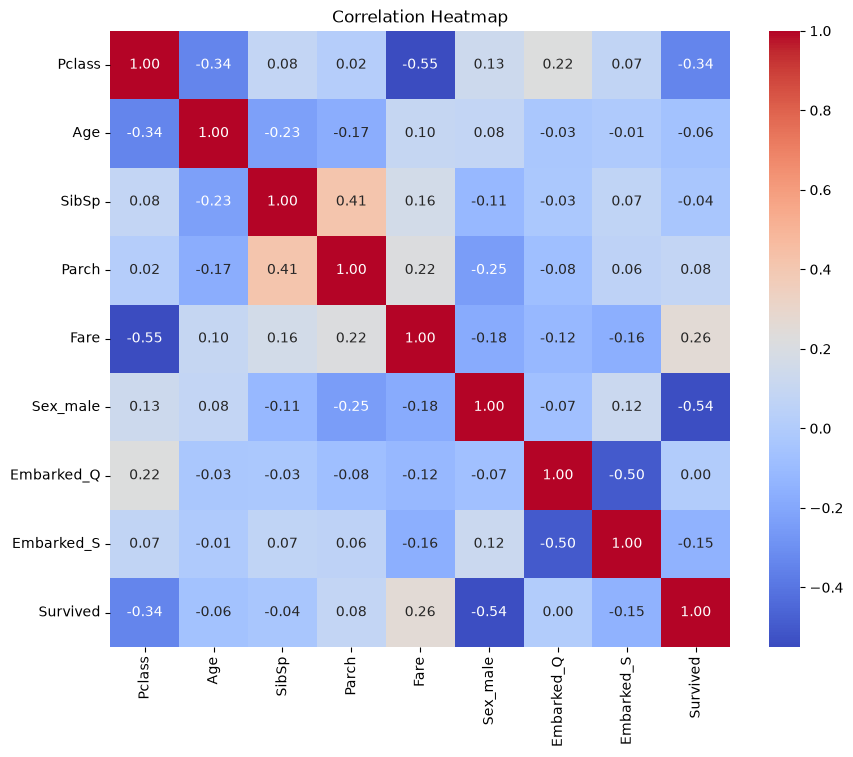

In [11]:
# see patterns
corr=pd.concat([X,y],axis=1).corr()



plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f')


plt.title('Correlation Heatmap')
plt.show()

In [12]:
#testing data/training
X_train,X_test,y_train,y_test=train_test_split(


    X,y,test_size=0.2,random_state=42,stratify=y
)

In [13]:
#regression
model=LogisticRegression(max_iter=1000)


model.fit(X_train,y_train)


y_pred=model.predict(X_test)

Accuracy: 0.8044692737430168
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



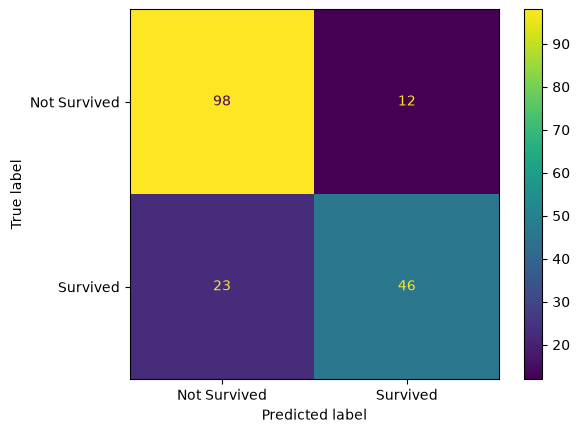

In [14]:
#checking accuracy
print('Accuracy:',accuracy_score(y_test,y_pred))


print(classification_report(y_test,y_pred))

cm=confusion_matrix(y_test,y_pred)


ConfusionMatrixDisplay(cm,display_labels=['Not Survived','Survived']).plot()
plt.show()

In [15]:
#checking weights
coef_df=pd.DataFrame({
    'Feature':X.columns,


    'Coefficient':model.coef_[0]

    
}).sort_values('Coefficient',ascending=False)

coef_df

,Feature,Coefficient
6,Embarked_Q,0.277863
4,Fare,0.002254
1,Age,-0.038536
3,Parch,-0.070927
2,SibSp,-0.245127
7,Embarked_S,-0.381281
0,Pclass,-1.090595
5,Sex_male,-2.558956
